# CancerDetector

In [1]:
import sys
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy import stats
from tqdm.notebook import tqdm as tqdm_notebook

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from methyldl.modelling.classifiers.cancer_detector import CancerDetectorClassifier

%load_ext autoreload
%autoreload 2

## Load the data

In [33]:
with open(ROOT /"App" / "labels_dict.json", "r") as f:
    label_dict = json.load(f)
cell_types_names = sorted(list(label_dict.values()))
del label_dict
cell_labels_to_names = {i: n for i, n in enumerate(cell_types_names)}
cell_names_to_labels = {n: i for i, n in enumerate(cell_types_names)}

In [3]:
DATA_PATH = ROOT / "Data" / "training_data" / "SoftLabelsTrainingData_205files_pooled_hg38_mincpg_4_minlen_10"
train_data = pd.read_parquet(DATA_PATH / "train.parquet")
val_data = pd.read_parquet(DATA_PATH / "valid.parquet")
test_data = pd.read_parquet(DATA_PATH / "test.parquet")

print("Train data:", len(train_data))
print("Validation data:", len(val_data))
print("Test data:", len(test_data))

Train data: 2910114
Validation data: 915902
Test data: 900610


In [50]:
train_on_target_mask = train_data["original_label"] == train_data["dmr_ctype_label"]
val_on_target_mask = val_data["original_label"] == val_data["dmr_ctype_label"]
test_on_target_mask = test_data["original_label"] == test_data["dmr_ctype_label"]

### Data exploration

On veut quantifier le nombre de dmr qui ont au moins une paire (dmr, classe) avec k échantillons pour k = 1, ..., 10

In [4]:
results = []
col_dmr_label = "dmr_label"
total_dmrs = train_data[col_dmr_label].nunique()
total_reads = len(train_data)
for k in tqdm_notebook(range(1, 5)):
    # on calcule le nombre de dmr telles que toutes les paires (dmr, classe) ont au moins k échantillons
    n_dmr = train_data.groupby(col_dmr_label).filter(lambda x: (x["original_label"].value_counts() >= k).all())[col_dmr_label].nunique()
    # on calcule le nombre d'échantillons restants
    n_reads = train_data.groupby(col_dmr_label).filter(lambda x: (x["original_label"].value_counts() >= k).all()).shape[0]

    results.append({
        "k": k,
        "n_dmr": n_dmr,
        "n_reads": n_reads,
        "pct_dmr": n_dmr / total_dmrs,
        "pct_reads": n_reads / total_reads
    })
pd.DataFrame(results)

  0%|          | 0/4 [00:00<?, ?it/s]

,k,n_dmr,n_reads,pct_dmr,pct_reads
0,1,843,2910114,1.000000,1.000000
1,2,743,2857006,0.881376,0.981751
2,3,695,2809063,0.824437,0.965276
3,4,655,2755533,0.776987,0.946881


## Train and evaluate CancerDetector

### Demo with class prior estimated from training data frequencies

In [6]:
cd_clf = CancerDetectorClassifier()
cd_clf.fit(
    train_data,
    col_n_meth_cpgs="M",
    col_n_unmeth_cpgs="U",
    col_marker_label="dmr_ctype_label",
    eps_beta_fit=0.01,
    class_prior_type="train_freq",
    # verbose=True,
)

In [7]:
train_probas, train_lhs = cd_clf.predict_proba(
    train_data, return_likelihoods=True, verbose=True
)
val_probas, val_lhs = cd_clf.predict_proba(
    val_data, return_likelihoods=True, verbose=True
)
test_probas, test_lhs = cd_clf.predict_proba(
    test_data, return_likelihoods=True, verbose=True
)

100%|██████████| 900610/900610 [00:14<00:00, 62116.78it/s]


In [8]:
# compute predicted labels and ground truth labels for train, val and test sets
train_preds = np.argmax(train_probas, axis=1)
train_gt = train_data["original_label"].to_numpy()
val_preds = np.argmax(val_probas, axis=1)
val_gt = val_data["original_label"].to_numpy()
test_preds = np.argmax(test_probas, axis=1)
test_gt = test_data["original_label"].to_numpy()

In [34]:
train_clf_report = classification_report(train_gt, train_preds, target_names=cell_types_names)
val_clf_report = classification_report(val_gt, val_preds, target_names=cell_types_names)
test_clf_report = classification_report(test_gt, test_preds, target_names=cell_types_names)

In [35]:
print("Train classification report:\n", train_clf_report)

Train classification report:
                    precision    recall  f1-score   support

       Adipocytes       0.22      0.01      0.01     28149
       Bladder-Ep       0.54      0.02      0.04     68848
          Blood-B       0.64      0.04      0.07     69003
     Blood-Granul       0.57      0.03      0.05     31038
 Blood-Mono+Macro       0.23      0.02      0.04    191079
         Blood-NK       0.42      0.03      0.05     24295
          Blood-T       0.12      0.66      0.20    312297
      Bone-Osteob       0.36      0.02      0.04     16843
  Breast-Basal-Ep       0.57      0.03      0.06     40535
Breast-Luminal-Ep       0.31      0.02      0.04     26426
         Colon-Ep       0.80      0.03      0.05    122116
      Colon-Fibro       0.06      0.00      0.00     25812
     Dermal-Fibro       0.16      0.02      0.03     15386
         Endothel       0.12      0.39      0.18    311796
       Epid-Kerat       0.34      0.03      0.05     16369
       Eryth-prog       0

In [36]:
print(f"Val classification report:\n{val_clf_report}")

Val classification report:
                   precision    recall  f1-score   support

       Adipocytes       0.44      0.01      0.01     27690
       Bladder-Ep       0.38      0.02      0.04     17242
          Blood-B       0.50      0.03      0.06     15536
     Blood-Granul       0.76      0.02      0.05     28653
 Blood-Mono+Macro       0.18      0.02      0.04     42738
         Blood-NK       0.68      0.03      0.05     23396
          Blood-T       0.09      0.64      0.15     72647
      Bone-Osteob       0.22      0.02      0.04      3609
  Breast-Basal-Ep       0.64      0.03      0.06     19253
Breast-Luminal-Ep       0.58      0.02      0.04     24973
         Colon-Ep       0.60      0.03      0.05     21524
      Colon-Fibro       0.13      0.00      0.00     12507
     Dermal-Fibro       0.08      0.01      0.02      3297
         Endothel       0.07      0.39      0.13     62814
       Epid-Kerat       0.21      0.02      0.04      3508
       Eryth-prog       0.45

In [37]:
# compute class-wise accuracy for train, val and test sets
def compute_class_wise_acc(y_true, y_pred, class_labels):
    acc_per_class = {}
    for label in class_labels:
        idx = y_true == label
        acc = accuracy_score(y_true[idx], y_pred[idx])
        acc_per_class[cell_labels_to_names[label]] = acc
    return acc_per_class

train_cw_acc = compute_class_wise_acc(train_gt, train_preds, class_labels=cell_names_to_labels.values())
val_cw_acc = compute_class_wise_acc(val_gt, val_preds, class_labels=cell_names_to_labels.values())
test_cw_acc = compute_class_wise_acc(test_gt, test_preds, class_labels=cell_names_to_labels.values())

pd.DataFrame({
    "train": train_cw_acc,
    "validation": val_cw_acc,
    "test": test_cw_acc,
})

,train,validation,test
Adipocytes,0.005897,0.005273,0.004120
Bladder-Ep,0.022528,0.019661,0.019873
Blood-B,0.037143,0.034179,0.036119
Blood-Granul,0.026065,0.024500,0.025137
Blood-Mono+Macro,0.020206,0.023235,0.020849
Blood-NK,0.028360,0.025859,0.026853
Blood-T,0.660311,0.636489,0.638662
Bone-Osteob,0.022977,0.022167,0.024100
Breast-Basal-Ep,0.030097,0.029138,0.036836
Breast-Luminal-Ep,0.019223,0.023385,0.019655


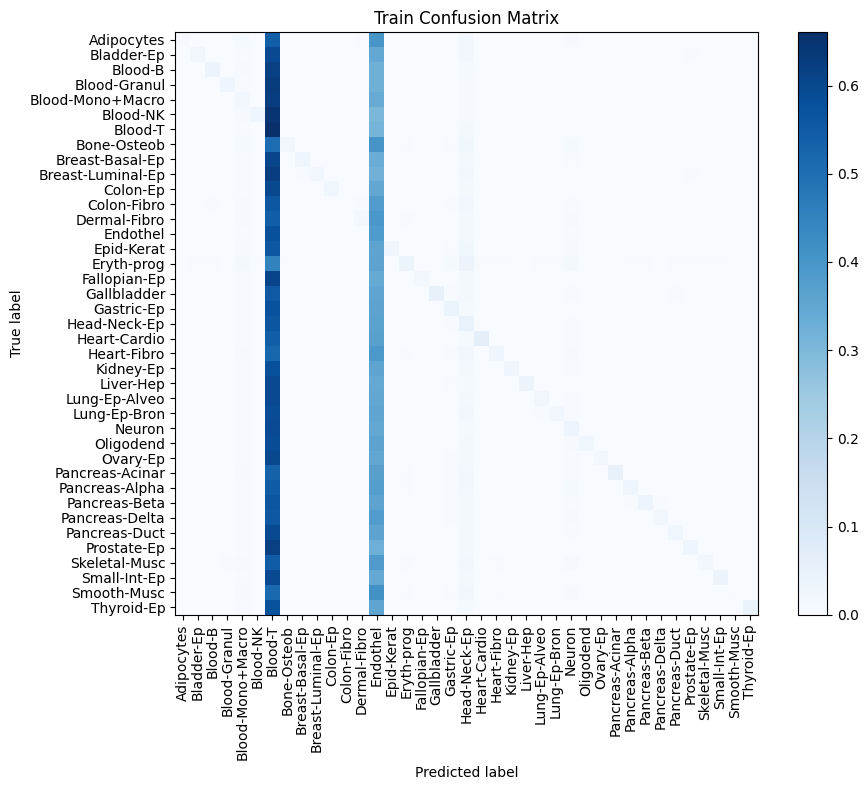

In [44]:
# confusion matrices
train_cm = confusion_matrix(train_gt, train_preds)
val_cm = confusion_matrix(val_gt, val_preds)
test_cm = confusion_matrix(test_gt, test_preds)

def plot_cm(cm, class_names, title, row_normalization=False):
    if row_normalization:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_cm(train_cm, class_names=cell_types_names, title="Train Confusion Matrix", row_normalization=True)

In [56]:
train_lhs[~train_on_target_mask][0]

array([5.41085256e-01, 6.97846162e-01, 7.51266036e-01, 7.09846983e-01,
       7.02587853e-01, 7.19314135e-01, 6.94719100e-01, 5.44495491e-01,
       6.57913271e-01, 7.32497853e-01, 6.22303022e-01, 5.95923417e-01,
       6.22443832e-01, 6.56478686e-01, 5.70023205e-01, 6.75661116e-08,
       7.22528444e-01, 6.49186624e-01, 5.93538082e-01, 6.07613472e-01,
       5.37879529e-01, 4.43860950e-01, 6.86549916e-01, 7.05031736e-01,
       6.72140891e-01, 6.83815862e-01, 6.57255174e-01, 6.80095038e-01,
       6.98814693e-01, 5.70937384e-01, 6.14370224e-01, 6.22991470e-01,
       6.05689358e-01, 6.83975193e-01, 7.10331367e-01, 4.96136779e-01,
       6.03326674e-01, 4.69616927e-01, 6.58581090e-01])

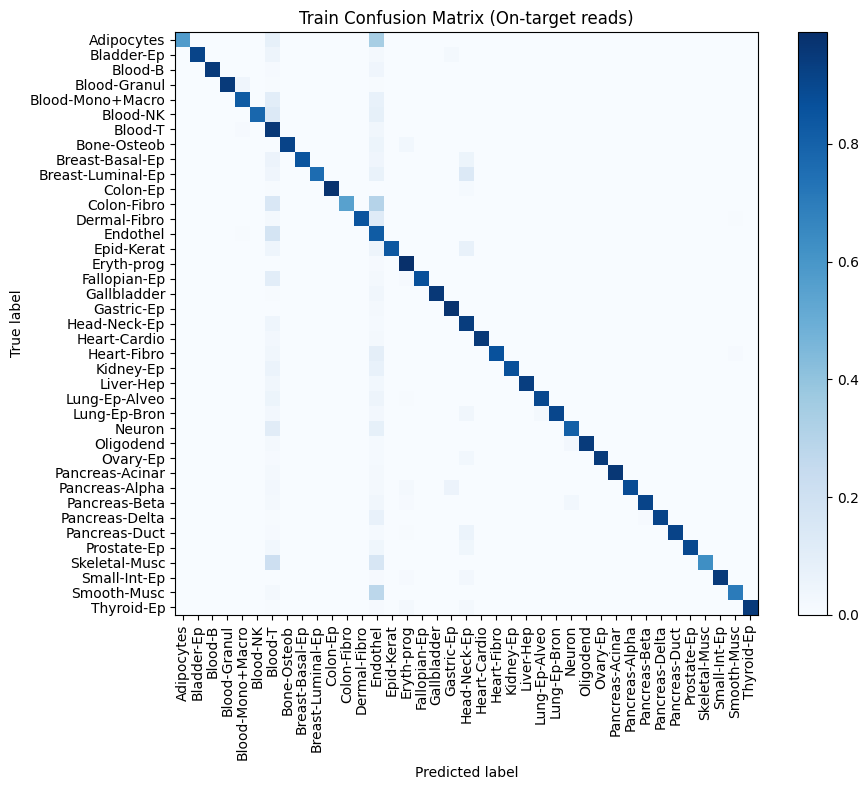

In [53]:
# confusion matrices for on-target reads only
train_cm_on_target = confusion_matrix(train_gt[train_on_target_mask], train_preds[train_on_target_mask])
val_cm_on_target = confusion_matrix(val_gt[val_on_target_mask], val_preds[val_on_target_mask])
test_cm_on_target = confusion_matrix(test_gt[test_on_target_mask], test_preds[test_on_target_mask])

plot_cm(train_cm_on_target, class_names=cell_types_names, title="Train Confusion Matrix (On-target reads)", row_normalization=True)

In [42]:
train_cnt_per_cell_type = train_data.groupby("original_label").agg(count = ("original_label", "count")).reset_index()
train_cnt_per_cell_type["cell_type"] = train_cnt_per_cell_type["original_label"].map(cell_labels_to_names)
train_cnt_per_cell_type.sort_values("count", ascending=False)

,original_label,count,cell_type
6,6,312297,Blood-T
13,13,311796,Endothel
19,19,208030,Head-Neck-Ep
4,4,191079,Blood-Mono+Macro
18,18,189752,Gastric-Ep
26,26,166440,Neuron
22,22,130019,Kidney-Ep
10,10,122116,Colon-Ep
23,23,112077,Liver-Hep
36,36,78816,Small-Int-Ep


It seems that the class prior pushes the less frequent classes to be predicted less often.

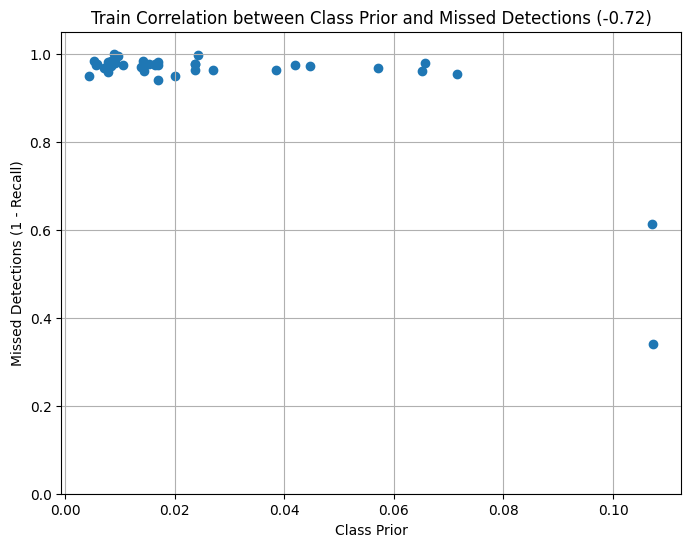

In [14]:
# correlation between the ratio (FN / (FN + TP)) (ie 1-recall, or missed detections) and the class prior
train_cm_norm = train_cm.astype("float") / train_cm.sum(axis=1)[:, np.newaxis]
class_priors = np.bincount(train_gt) / len(train_gt)
missed_detections = 1 - np.diag(train_cm_norm)
corr = np.corrcoef(class_priors, missed_detections)[0, 1]
plt.figure(figsize=(8, 6))
plt.scatter(class_priors, missed_detections)
plt.ylim(0, 1.05)
plt.xlabel("Class Prior")
plt.ylabel("Missed Detections (1 - Recall)")
plt.title(f"Train Correlation between Class Prior and Missed Detections ({corr:.2f})")
plt.grid(True)
plt.show()

### Demo with uniform class prior

In [18]:
cd_clf_unif = CancerDetectorClassifier()
cd_clf_unif.fit(
    train_data,
    col_n_meth_cpgs="M",
    col_n_unmeth_cpgs="U",
    col_marker_label="dmr_ctype_label",
    eps_beta_fit=0.01,
    class_prior_type="uniform",
    # verbose=True,
)

In [19]:
train_probas_unif, train_lhs_unif = cd_clf_unif.predict_proba(
    train_data, return_likelihoods=True, verbose=True
)
val_probas_unif, val_lhs_unif = cd_clf_unif.predict_proba(
    val_data, return_likelihoods=True, verbose=True
)
test_probas_unif, test_lhs_unif = cd_clf_unif.predict_proba(
    test_data, return_likelihoods=True, verbose=True
)

100%|██████████| 900610/900610 [00:15<00:00, 56741.81it/s]


In [20]:
# compute predicted labels and ground truth labels for train, val and test sets
train_preds_unif = np.argmax(train_probas_unif, axis=1)
train_gt = train_data["original_label"].to_numpy()
val_preds_unif = np.argmax(val_probas_unif, axis=1)
val_gt = val_data["original_label"].to_numpy()
test_preds_unif = np.argmax(test_probas_unif, axis=1)
test_gt = test_data["original_label"].to_numpy()

In [ ]:
# compute classification reports and confusion matrices for the uniform class prior model
train_clf_report_unif = classification_report(train_gt, train_preds_unif, target_names=cell_types_names)
val_clf_report_unif = classification_report(val_gt, val_preds_unif, target_names=cell_types_names)
test_clf_report_unif = classification_report(test_gt, test_preds_unif, target_names=cell_types_names)

train_cm_unif = confusion_matrix(train_gt, train_preds_unif)
val_cm_unif = confusion_matrix(val_gt, val_preds_unif)
test_cm_unif = confusion_matrix(test_gt, test_preds_unif)

train_cw_acc_unif = compute_class_wise_acc(train_gt, train_preds_unif, class_labels=cell_names_to_labels.values())
val_cw_acc_unif = compute_class_wise_acc(val_gt, val_preds_unif, class_labels=cell_names_to_labels.values())
test_cw_acc_unif = compute_class_wise_acc(test_gt, test_preds_unif, class_labels=cell_names_to_labels.values())
cw_acc_df_unif = pd.DataFrame({
    "train": train_cw_acc_unif,
    "validation": val_cw_acc_unif,
    "test": test_cw_acc_unif,
})

In [22]:
print(train_clf_report_unif)

                   precision    recall  f1-score   support

       Thyroid-Ep       0.03      0.02      0.02     28149
     Blood-Granul       0.26      0.03      0.05     68848
     Heart-Cardio       0.03      0.17      0.06     69003
    Lung-Ep-Alveo       0.03      0.05      0.03     31038
        Kidney-Ep       0.26      0.02      0.03    191079
           Neuron       0.01      0.33      0.02     24295
        Liver-Hep       0.48      0.03      0.06    312297
     Dermal-Fibro       0.02      0.04      0.03     16843
       Bladder-Ep       0.02      0.09      0.04     40535
          Blood-T       0.01      0.08      0.02     26426
     Fallopian-Ep       0.33      0.03      0.05    122116
        Oligodend       0.01      0.01      0.01     25812
         Endothel       0.03      0.02      0.03     15386
         Colon-Ep       0.49      0.02      0.03    311796
     Head-Neck-Ep       0.06      0.03      0.04     16369
          Blood-B       0.03      0.23      0.05     41

In [23]:
cw_acc_df_unif

,train,validation,test
Thyroid-Ep,0.016484,0.015565,0.014200
Blood-Granul,0.025680,0.023489,0.023376
Heart-Cardio,0.170297,0.157119,0.153111
Lung-Ep-Alveo,0.050164,0.049698,0.048151
Kidney-Ep,0.018212,0.020871,0.020165
Neuron,0.332661,0.308215,0.320951
Liver-Hep,0.031669,0.032871,0.031663
Dermal-Fibro,0.035861,0.034636,0.037396
Bladder-Ep,0.092685,0.087571,0.096824
Blood-T,0.083932,0.082169,0.082444


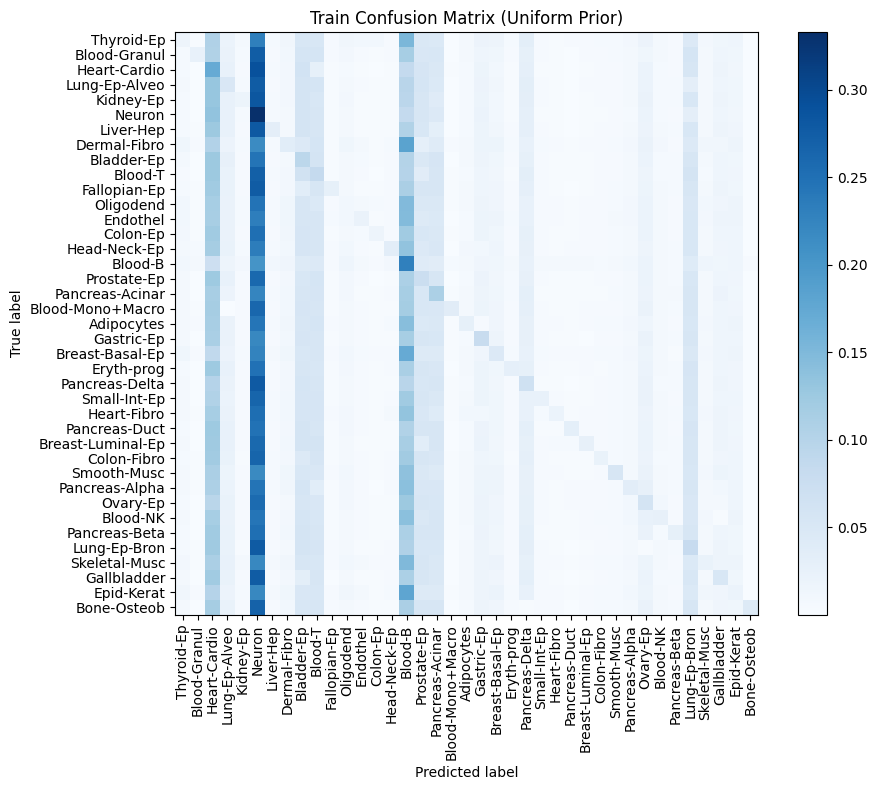

In [ ]:
plot_cm(train_cm_unif, class_names=cell_types_names, title="Train Confusion Matrix (Uniform Prior)", row_normalization=True)

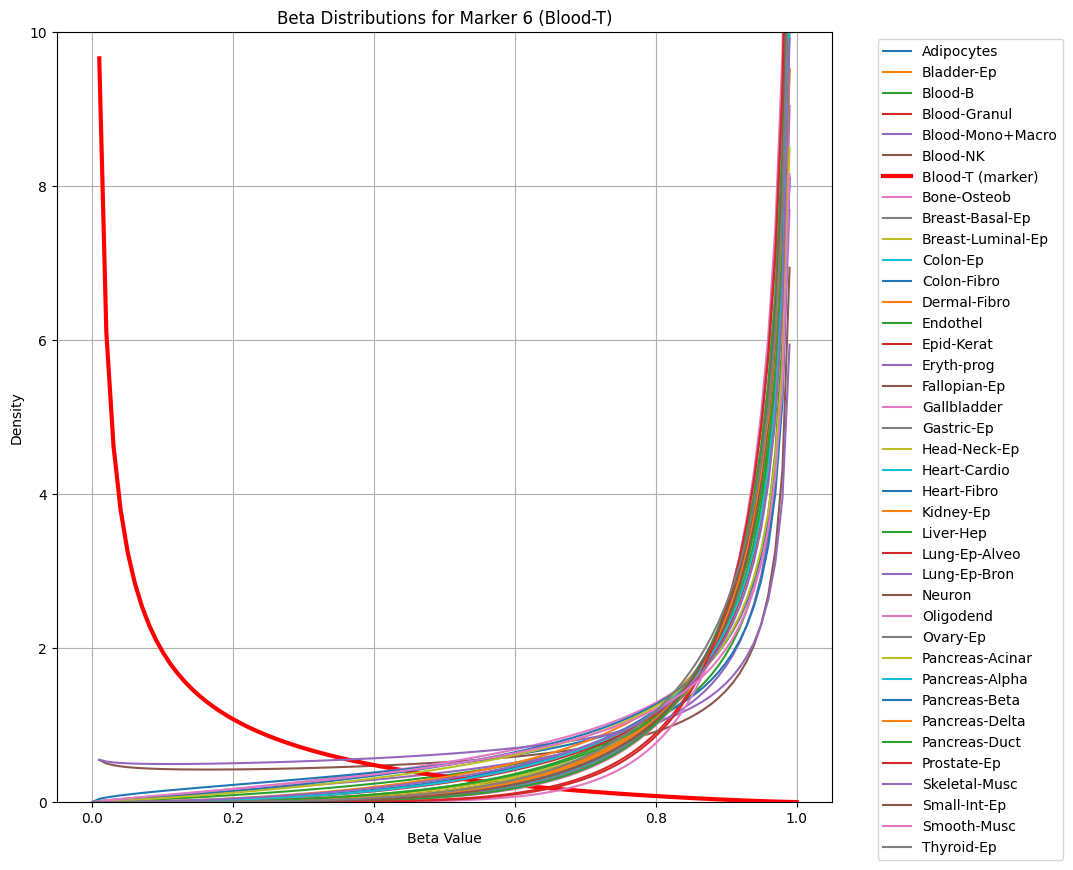

In [60]:
# plot the beta distributions 
marker_label = 6
marker_ctype_name = cell_labels_to_names[marker_label]
eta_per_ctype = cd_clf_unif.param_eta_matrix[marker_label, :]
rho_per_ctype = cd_clf_unif.param_rho_matrix[marker_label, :]

x = np.linspace(0, 1, 100)
plt.figure(figsize=(10, 10))
for ctype_label, ctype_name in cell_labels_to_names.items():
    eta = eta_per_ctype[ctype_label]
    rho = rho_per_ctype[ctype_label]
    y = stats.beta.pdf(x, eta, rho)
    if ctype_label == marker_label:
        plt.plot(x, y, label=f"{ctype_name} (marker)", linewidth=3, color="red")
    else:
        plt.plot(x, y, label=ctype_name)
plt.title(f"Beta Distributions for Marker {marker_label} ({marker_ctype_name})")
plt.xlabel("Beta Value")
plt.ylabel("Density")
plt.ylim(0, 10)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

## Train CancerDetector Classifier and generate ios

ios are input/outputs of deconvolvers (input: prediction matricess, output: cell type proportions)